In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [2]:
df=pd.read_csv("C:/Users/tusha/Excelr_Assignment/blogs.csv")

In [3]:
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [8]:

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())


Dataset Shape: (2000, 2)

Column Names: ['Data', 'Labels']


In [9]:
# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Data      0
Labels    0
dtype: int64


In [10]:
# Explore category distribution
print("\nCategory Distribution:\n", df['Labels'].value_counts())


Category Distribution:
 Labels
alt.atheism                 100
comp.graphics               100
talk.politics.misc          100
talk.politics.mideast       100
talk.politics.guns          100
soc.religion.christian      100
sci.space                   100
sci.med                     100
sci.electronics             100
sci.crypt                   100
rec.sport.hockey            100
rec.sport.baseball          100
rec.motorcycles             100
rec.autos                   100
misc.forsale                100
comp.windows.x              100
comp.sys.mac.hardware       100
comp.sys.ibm.pc.hardware    100
comp.os.ms-windows.misc     100
talk.religion.misc          100
Name: count, dtype: int64


### Text Cleaning and Preprocessing

In [11]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)      # Remove non-alphabetic characters
    text = text.lower()                         # Lowercase
    tokens = text.split()                       # Tokenize
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]  # Remove stopwords + stem
    return ' '.join(tokens)

df['clean_text'] = df['Data'].apply(clean_text)

# Preview cleaned text
print("\nCleaned Text Sample:\n", df['clean_text'].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tusha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Cleaned Text Sample:
 0    path cantaloup srv cs cmu edu magnesium club c...
1    newsgroup alt atheism path cantaloup srv cs cm...
2    path cantaloup srv cs cmu edu da news harvard ...
3    path cantaloup srv cs cmu edu magnesium club c...
4    xref cantaloup srv cs cmu edu alt atheism talk...
Name: clean_text, dtype: object


### Feature Extraction using TF-IDF

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to TF-IDF vectors
tfidf = TfidfVectorizer(max_features=3000)  # Limit to 3000 features for performance
X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['Labels']  # Target labels


In [13]:
print("TF-IDF Feature Matrix Shape:", X.shape)


TF-IDF Feature Matrix Shape: (2000, 3000)


 ### Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Train Naive Bayes Classifier

In [15]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train the model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)


MultinomialNB()

🔍 Accuracy: 0.8225

📋 Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.86      0.60      0.71        20
           comp.graphics       0.81      0.85      0.83        20
 comp.os.ms-windows.misc       0.82      0.90      0.86        20
comp.sys.ibm.pc.hardware       0.68      0.85      0.76        20
   comp.sys.mac.hardware       0.94      0.80      0.86        20
          comp.windows.x       0.82      0.70      0.76        20
            misc.forsale       0.90      0.90      0.90        20
               rec.autos       0.77      1.00      0.87        20
         rec.motorcycles       0.89      0.80      0.84        20
      rec.sport.baseball       0.94      0.85      0.89        20
        rec.sport.hockey       0.83      1.00      0.91        20
               sci.crypt       0.95      1.00      0.98        20
         sci.electronics       0.81      0.65      0.72        20
                 sci.med     

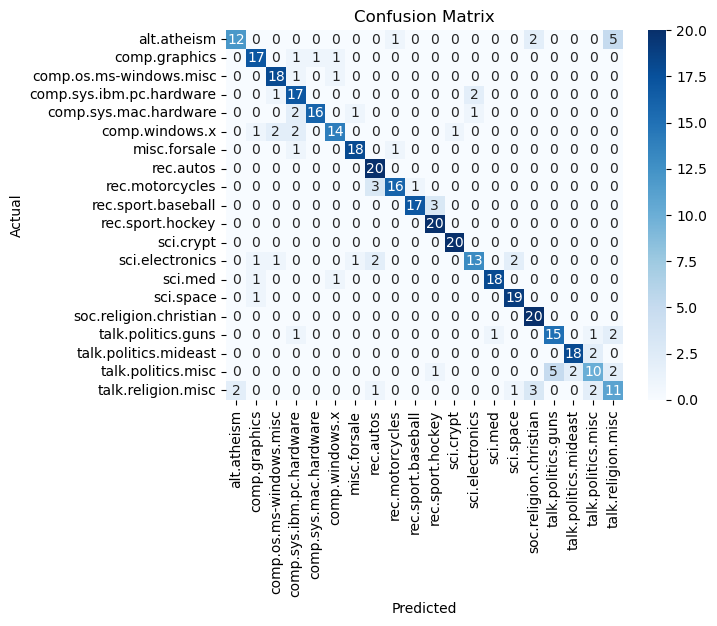

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred = nb_model.predict(X_test)

# Evaluate the model
print("🔍 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

# Optional: View confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nb_model.classes_, yticklabels=nb_model.classes_, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


##  Sentiment Analysis

In [18]:
from textblob import TextBlob


In [19]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis
df['Sentiment'] = df['Data'].apply(get_sentiment)

# Preview
print(df[['Data', 'Sentiment']].head())


                                                Data Sentiment
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Positive
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  Negative
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  Positive
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Positive
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  Positive


C:\Users\tusha\AppData\Local\Temp\ipykernel_4904\2072910735.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='pastel')


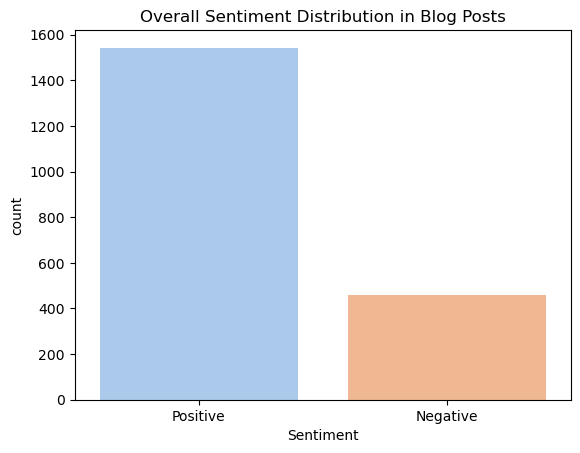

In [22]:


sns.countplot(data=df, x='Sentiment', palette='pastel')
plt.title('Overall Sentiment Distribution in Blog Posts')
plt.show()


 ### Sentiment by Category

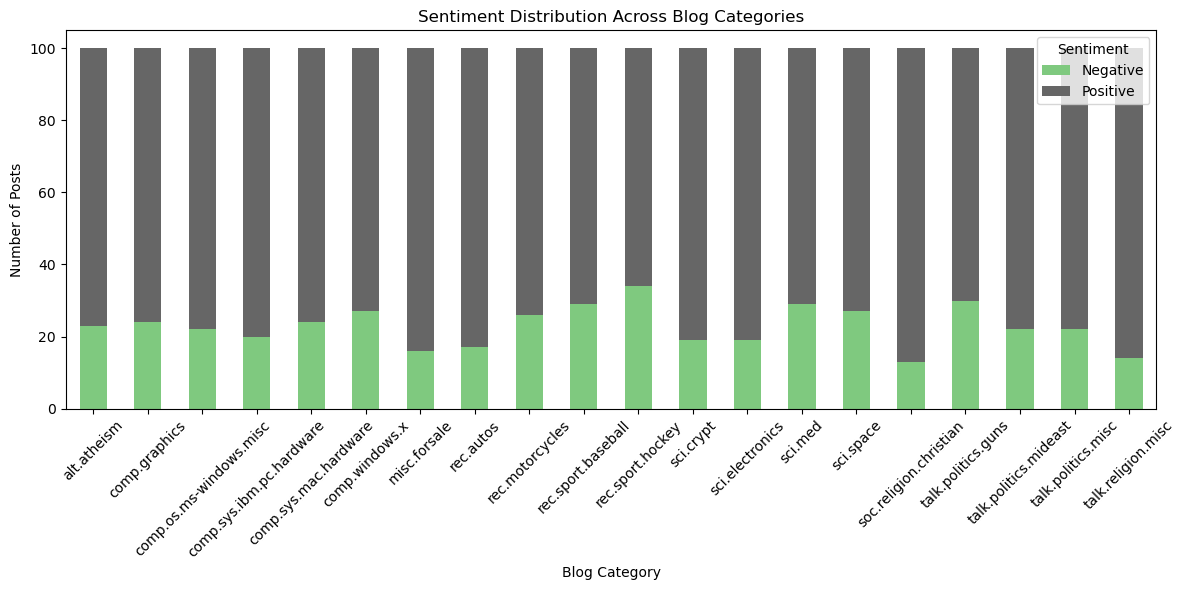

In [21]:
# Sentiment counts per category
sentiment_by_category = df.groupby(['Labels', 'Sentiment']).size().unstack().fillna(0)

# Plot
sentiment_by_category.plot(kind='bar', stacked=True, colormap='Accent', figsize=(12,6))
plt.title("Sentiment Distribution Across Blog Categories")
plt.xlabel("Blog Category")
plt.ylabel("Number of Posts")
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
